# Implementation of all the types of Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score

In [2]:
data = pd.DataFrame({
    'Hours': [1, 2, 3, 4, 5, 6, 7],
    'Marks': [2, 4, 5, 4, 5, 7, 8]
})

x = data["Hours"].values
y = data["Marks"].values

In [3]:
X_train,X_test,y_train,y_test = train_test_split(x,y,random_state = 42, test_size=0.2)

# Simple Linear Regression from Scratch

In [4]:
class LinearRegression :
    
    def __init__(self):
        self.slope_ = None
        self.intercept_ = None
    
    def fit(self,x,y):
        x_mean = np.mean(x)
        y_mean = np.mean(y)
        
        self.slope_ = np.dot((x-x_mean),(y-y_mean))/np.dot((x-x_mean),(x-x_mean))
        
        self.intercept_ = y_mean - self.slope_ * x_mean
    
    def predict(self,x):
        y = x*self.slope_ + self.intercept_
        return y
    

In [5]:
lr = LinearRegression()
lr.fit(X_train,y_train)
predict = lr.predict(y_test)
print(predict)

[3.1 4.9]


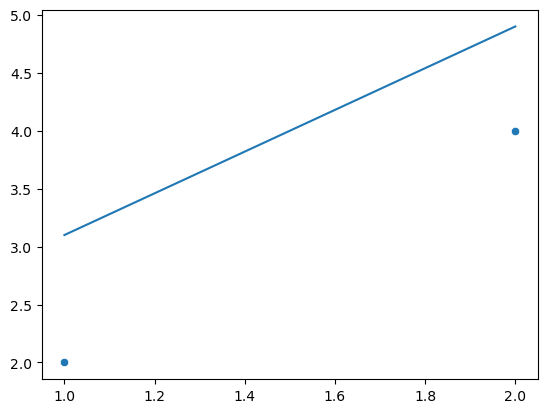

In [6]:
sns.scatterplot(x=X_test,y=y_test)
sns.lineplot(x=X_test,y=predict)
plt.show()

In [7]:
accuracy = r2_score(y_test,predict)
print(accuracy)

-0.010000000000000009


In [8]:
accuracy = mean_squared_error(y_test,predict)
print(accuracy)

1.01


# Linear Regression using Library

In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr = LinearRegression()
X_train = X_train.reshape(-1,1)
y_train = y_train.reshape(-1,1)
X_test = X_test.reshape(-1,1)
y_test = y_test.reshape(-1,1)
lr.fit(X_train,y_train)
predicted = lr.predict(X_test)

In [11]:
accuracy = r2_score(y_test,predicted)
print(accuracy)
accuracy = mean_squared_error(y_test,predicted)
print(accuracy)

0.5749999999999997
0.42500000000000027


# Multiple Linear Regression From Scratch

In [12]:
class MultipleLinearRegression:
    
    def __init__(self):
        self.weights = None
        
    def fit(self,x,y):
        ones = np.ones((x.shape[0],1))
        x = np.hstack((ones,x))
        
        xtranspose = x.T
        self.weights = np.linalg.pinv(xtranspose @ x) @ xtranspose @ y
        
    
    def predict(self, X):
        # Add bias column
        ones = np.ones((X.shape[0], 1))
        X = np.hstack((ones, X))

        return X @ self.weights

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
data = {
    "area": [850, 900, 1200, 1500, 1800, 2000, 2300, 2600],
    "bedrooms": [2, 2, 3, 3, 4, 4, 5, 5],
    "age": [20, 15, 18, 10, 8, 5, 3, 1],
    "price": [30000, 35000, 50000, 65000, 80000, 90000, 105000, 120000]
}

df = pd.DataFrame(data)
print(df)
x = df[["area","bedrooms","age"]].values
standard = StandardScaler()
x = standard.fit_transform(x)
y = df["price"]

   area  bedrooms  age   price
0   850         2   20   30000
1   900         2   15   35000
2  1200         3   18   50000
3  1500         3   10   65000
4  1800         4    8   80000
5  2000         4    5   90000
6  2300         5    3  105000
7  2600         5    1  120000


In [15]:
X_train,X_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [16]:
lr = MultipleLinearRegression()
lr.fit(X_train,y_train)
predicted = lr.predict(X_test)
print(X_test)
print(predicted)

[[-1.23590096 -1.34164079  0.75809804]
 [ 0.59198618  0.4472136  -0.75809804]]
[33960.5418139  89816.45072634]


In [17]:
print(r2_score(y_test,predicted))

0.999263362871729


# Polynomial Regression from scratch

In [18]:
def createPolynomial(x,degree):
    x = np.array(x)
    x_poly = np.ones((x.shape[0],1))
    
    for d in (1,degree+1):
        x_poly = np.hstack((x_poly,((x**d).reshape(-1,1))))
    return x_poly

In [19]:
class PolynomialRegression:
    
    def __init__(self,degree=5):
        self.degree = degree
        self.weigths = None
        
    def fit(self,x,y):
        x = np.array(x)
        y = np.array(y)
        
        x_poly = createPolynomial(x,self.degree)
        
        #Normal Equation
        xTranspose = x_poly.T
        self.weights = np.linalg.pinv(xTranspose @ x_poly) @ xTranspose @ y
        
    def predict(self,x):
        x = np.array(x)
        x = createPolynomial(x,self.degree)
        return x @ self.weights
        

In [20]:
# Reproducibility
np.random.seed(42)

# Generate input feature
X = np.linspace(-10, 10, 100)

# Generate noise
noise = np.random.randn(100) * 10

# Polynomial relationship
y = 4 + 3*X + 2*(X**2) + noise

# Convert to DataFrame
df = pd.DataFrame({
    'X': X,
    'y': y
})

In [21]:
df.head()

,X,y
0,-10.000000,178.967142
1,-9.797980,165.224234
2,-9.595960,165.853888
3,-9.393939,167.540675
4,-9.191919,143.065466


In [22]:
x = df["X"]
y = df["y"]
X_train,X_test,y_train,y_test = train_test_split(x,y,random_state =42, test_size = 0.2)
pr = PolynomialRegression(3)
pr.fit(X_train,y_train)
predicted = pr.predict(X_test)
print(predicted)

[ 89.58613629  27.20727413  43.25331467  22.64955653  22.09682098
  19.64631409  30.05608058  73.71234299  90.13264186 212.68714875
  42.60085943  19.26738255  49.57889951  18.44771215 145.00396802
 153.24241513  58.05355894  61.45462235  74.8579639   18.85167801]


In [23]:
print(r2_score(y_test,predicted))
print(mean_squared_error(y_test,predicted))

0.8570225882223039
416.0630737716251


<Axes: xlabel='X', ylabel='y'>

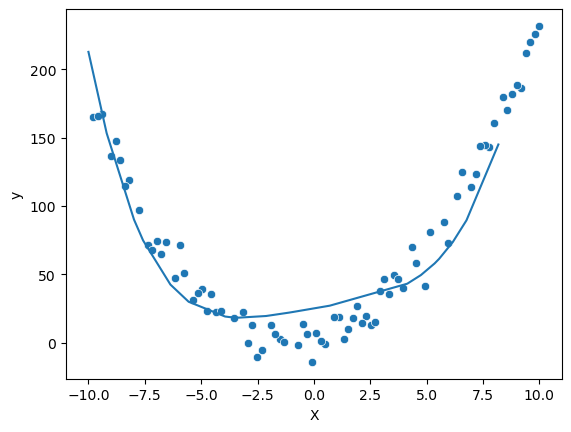

In [24]:
sns.scatterplot(x=X_train,y=y_train,data=data)
sns.lineplot(x=X_test,y=predicted,data=data)

# Linear Regression using Gradient Descent from Scratch

In [25]:
class GradientDescentLinearRegression:
    
    def __init__(self,learning_rate=0.01,epochs=2000):
        self.weights = None
        self.lr = learning_rate
        self.epochs= epochs
        
    def fit(self,x,y):
        m,n = x.shape
        
        x = np.hstack((np.ones((m,1)),x))
        self.weights = np.zeros(n+1)
        
        for _ in range(self.epochs):
            y_pred = x @ self.weights
            
            error = y_pred - y
            
            gradient = (1/m) * (x.T @ error)
            
            self.weights = self.weights - self.lr * gradient
    
    def predict(self,x):
        m = x.shape[0]
        x = np.hstack((np.ones((m,1)),x))
        
        return x @ self.weights

In [26]:
data = {
    "area": [850, 900, 1200, 1500, 1800, 2000, 2300, 2600],
    "bedrooms": [2, 2, 3, 3, 4, 4, 5, 5],
    "age": [20, 15, 18, 10, 8, 5, 3, 1],
    "price": [30000, 35000, 50000, 65000, 80000, 90000, 105000, 120000]
}

df = pd.DataFrame(data)
print(df)
x = df[["area","bedrooms"]].values
y = df["price"].values

   area  bedrooms  age   price
0   850         2   20   30000
1   900         2   15   35000
2  1200         3   18   50000
3  1500         3   10   65000
4  1800         4    8   80000
5  2000         4    5   90000
6  2300         5    3  105000
7  2600         5    1  120000


In [27]:
from sklearn.preprocessing import StandardScaler
stdScaler = StandardScaler()
x = stdScaler.fit_transform(x)

In [28]:
X_train,X_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [29]:
model = GradientDescentLinearRegression()
model.fit(X_train,y_train)
predict = model.predict(X_test)
print(predict)

[31869.11409759 87882.41580701]


In [30]:
print(r2_score(y_test,predict))
print(mean_squared_error(y_test,predict))

0.9905543078688605
7143304.674174303


# Implementation of Linear Regression using the sklearn library

In [31]:
data = {
    "area": [850, 900, 1200, 1500, 1800, 2000, 2300, 2600],
    "bedrooms": [2, 2, 3, 3, 4, 4, 5, 5],
    "age": [20, 15, 18, 10, 8, 5, 3, 1],
    "price": [30000, 35000, 50000, 65000, 80000, 90000, 105000, 120000]
}

df = pd.DataFrame(data)
print(df)
x = df[["area","bedrooms"]].values
y = df["price"].values

   area  bedrooms  age   price
0   850         2   20   30000
1   900         2   15   35000
2  1200         3   18   50000
3  1500         3   10   65000
4  1800         4    8   80000
5  2000         4    5   90000
6  2300         5    3  105000
7  2600         5    1  120000


In [32]:
from sklearn.preprocessing import StandardScaler
stdScaler = StandardScaler()
x = stdScaler.fit_transform(x)

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
X_train,X_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)
lr = LinearRegression()
lr.fit(X_train,y_train)
predicted = lr.predict(X_test)
print(predicted)

[33571.42857143 89682.53968254]


In [35]:
print(r2_score(y_test,predicted))
print(mean_squared_error(y_test,predicted))

0.9985840678481371
1070798.689846295
